In [42]:
import pandas as pd


In [43]:
df = pd.read_csv("retail_sales_dataset.csv")

In [44]:
df.shape

(1000, 9)

In [45]:
df.dtypes

,0
Transaction ID,int64
Date,object
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


In [46]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [47]:
df.select_dtypes(include='number').columns

Index(['Transaction ID', 'Age', 'Quantity', 'Price per Unit', 'Total Amount'], dtype='object')

In [48]:
df.select_dtypes(include='number').mean()

,0
Transaction ID,500.500
Age,41.392
Quantity,2.514
Price per Unit,179.890
Total Amount,456.000


In [49]:
df.select_dtypes(include='number').median()

,0
Transaction ID,500.5
Age,42.0
Quantity,3.0
Price per Unit,50.0
Total Amount,135.0


In [51]:
df.select_dtypes(include='number').mode()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
0,1,43.0,4.0,50.0,50.0
1,2,64.0,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN
...,...,...,...,...,...
995,996,NaN,NaN,NaN,NaN
996,997,NaN,NaN,NaN,NaN
997,998,NaN,NaN,NaN,NaN
998,999,NaN,NaN,NaN,NaN


In [52]:
df.select_dtypes(include='number').std()

,0
Transaction ID,288.819436
Age,13.681430
Quantity,1.132734
Price per Unit,189.681356
Total Amount,559.997632


In [53]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [54]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

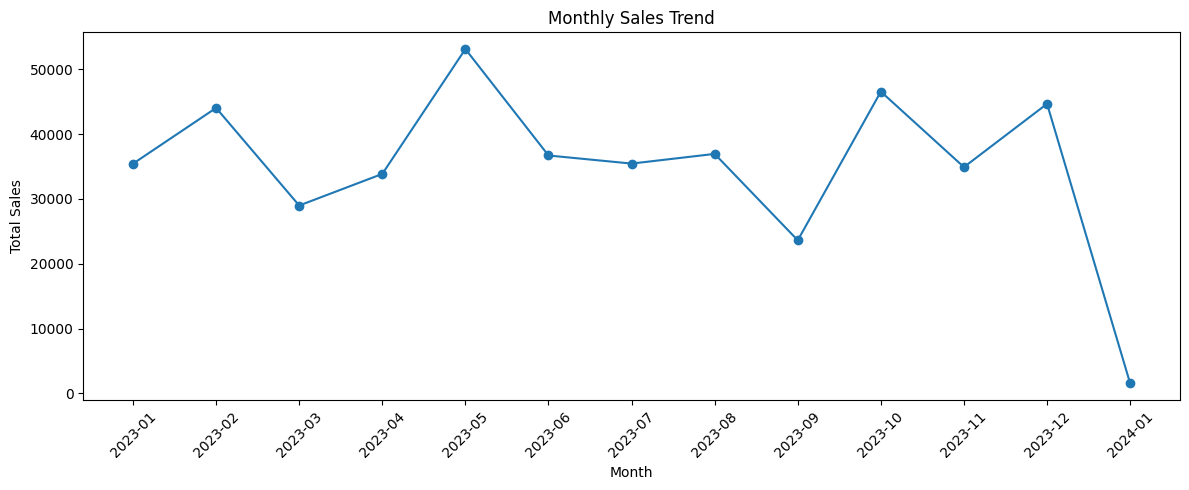

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observation: The monthly sales trend shows noticeable fluctuations in total sales throughout the year. Sales reached their highest level in May 2023, while the lowest recorded value appears in January 2024. Overall, sales did not follow a consistent upward or downward trend.

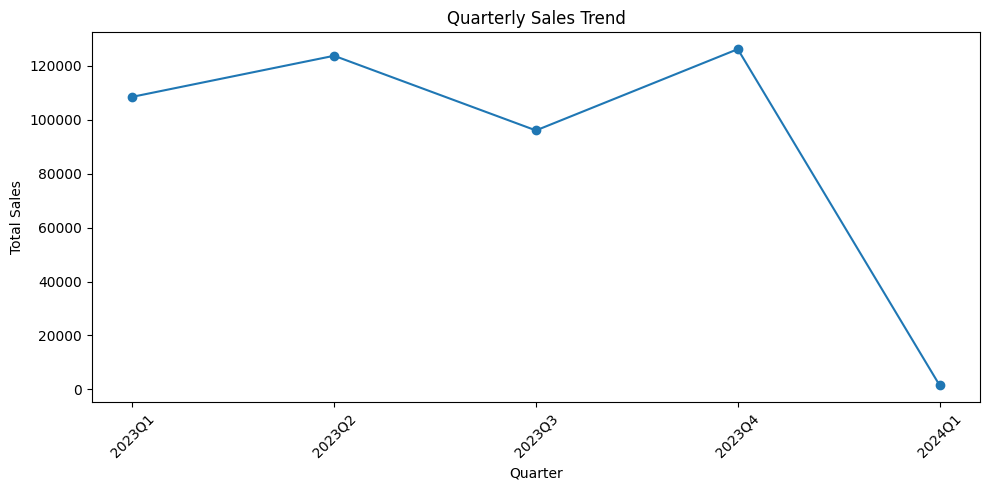

In [56]:
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()

quarterly_sales.index = quarterly_sales.index.astype(str)

plt.figure(figsize=(10, 5))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker='o')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Observation

The quarterly sales trend shows variations in total sales across the quarters. The differences between quarters indicate changes in sales performance over time. These patterns can help the business plan inventory, promotions, and marketing activities more effectively.

In [57]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['Below 18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [58]:
age_group_counts = df['Age Group'].value_counts().sort_index()
age_group_counts

,count
Age Group,
Below 18,21
18-25,148
26-35,205
36-45,202
46-55,229
56-65,195
65+,0


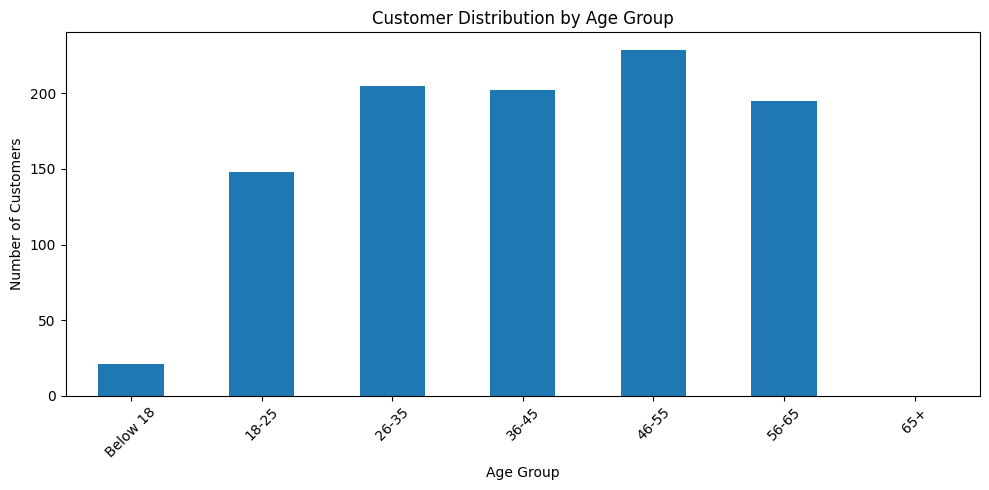

In [59]:
plt.figure(figsize=(10, 5))
age_group_counts.plot(kind='bar')
plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observation: The age-group analysis shows that customers are distributed across different age categories. The 46–55 age group has the highest number of customers, followed by the 26–35 and 36–45 age groups. The 65+ group has no customers in this dataset.

In [60]:
gender_counts = df['Gender'].value_counts()
gender_counts

,count
Gender,
Female,510
Male,490


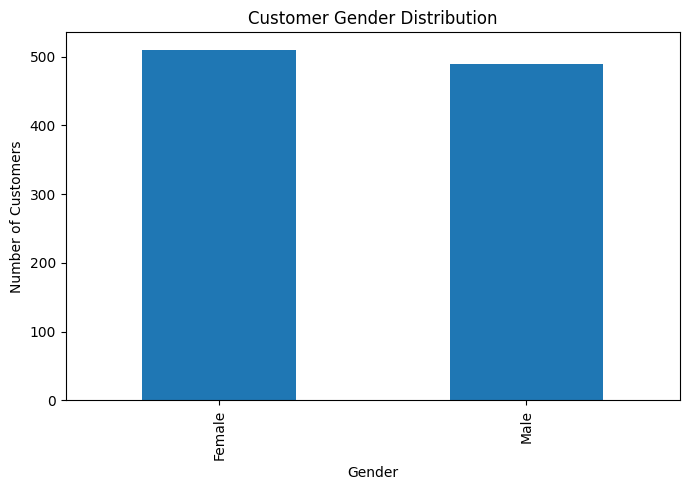

In [61]:
plt.figure(figsize=(7, 5))
gender_counts.plot(kind='bar')
plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

Observation: The gender distribution is nearly balanced, with female customers slightly outnumbering male customers in the dataset. This indicates that both genders contribute significantly to the customer base.

In [62]:
df['Product Category'].value_counts()

,count
Product Category,
Clothing,351
Electronics,342
Beauty,307


In [26]:
df['Product Category'].value_counts()


,count
Product Category,
Clothing,351
Electronics,342
Beauty,307


In [27]:
df['Product Category'].value_counts()

,count
Product Category,
Clothing,351
Electronics,342
Beauty,307


In [63]:
top_categories = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False).head(10)

top_categories


,Quantity
Product Category,
Clothing,894
Electronics,849
Beauty,771


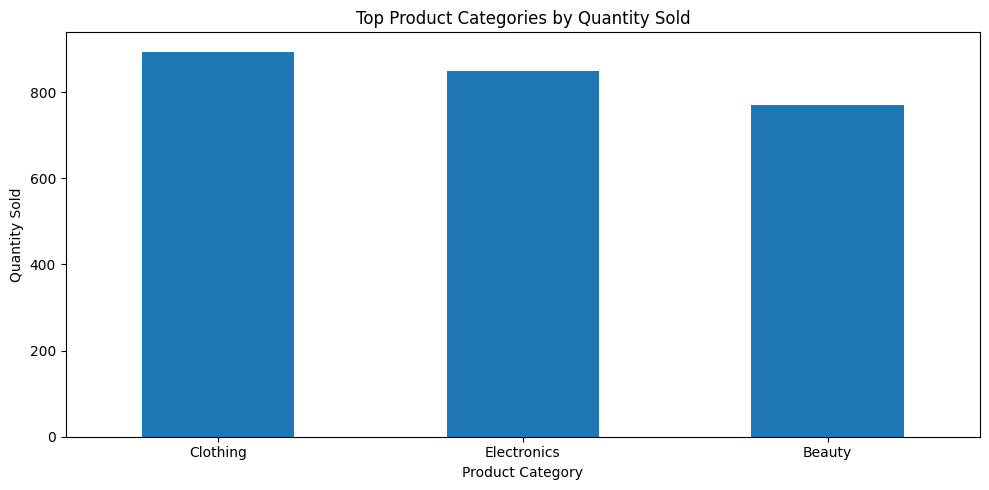

In [64]:
plt.figure(figsize=(10, 5))

top_categories.plot(kind='bar')

plt.title('Top Product Categories by Quantity Sold')
plt.xlabel('Product Category')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [65]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

category_revenue

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


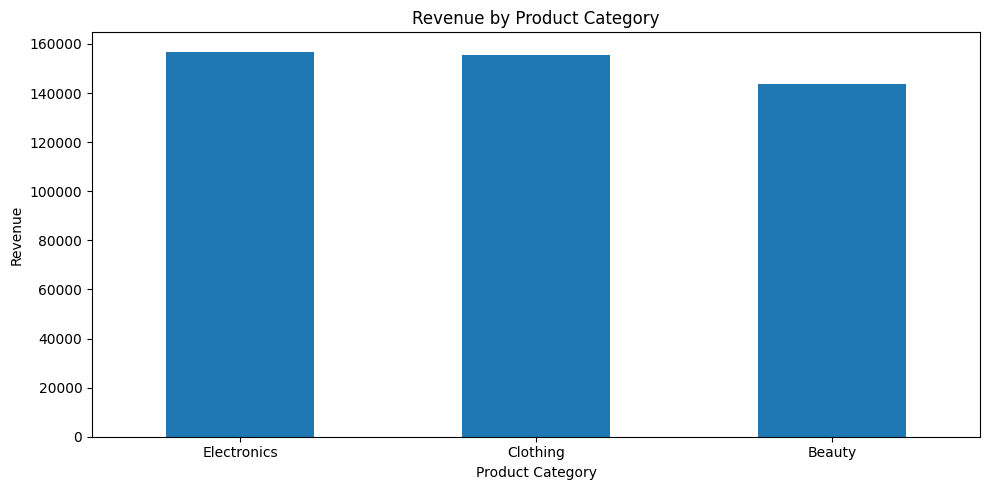

In [66]:
plt.figure(figsize=(10, 5))

category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The revenue analysis shows that Electronics generates the highest revenue, followed by Clothing and Beauty. This indicates that revenue performance does not exactly follow the same ranking as quantity sold. Electronics is therefore particularly important from a financial perspective, while Clothing performs strongly in terms of sales volume.

In [67]:
numeric_df = df.select_dtypes(include='number')

correlation = numeric_df.corr()

correlation

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


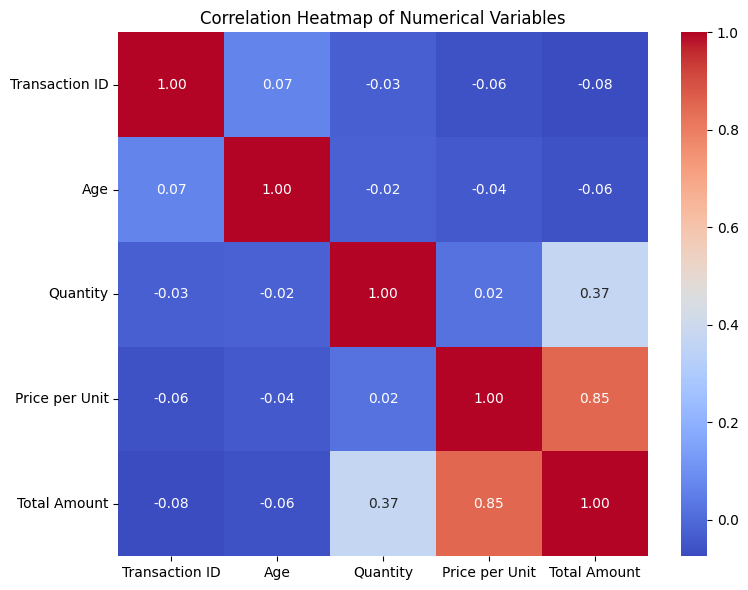

In [68]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows a strong positive relationship between Price per Unit and Total Amount. Quantity also has a positive relationship with Total Amount, although it is weaker. The results indicate that transaction value is influenced by both unit price and quantity.

In [69]:
gender_category_sales = df.groupby(
    ['Product Category', 'Gender']
)['Total Amount'].sum().unstack()

<Figure size 1000x500 with 0 Axes>

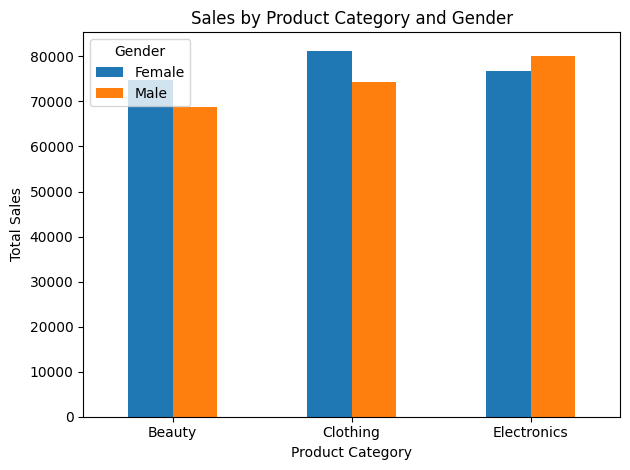

In [70]:
plt.figure(figsize=(10, 5))

gender_category_sales.plot(kind='bar')

plt.title('Sales by Product Category and Gender')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The gender distribution shows that female customers slightly outnumber male customers. This indicates a nearly balanced customer base, suggesting that marketing strategies should consider both male and female customers rather than focusing heavily on one gender.

### Conclusion

The exploratory data analysis provided useful insights into customer demographics, sales trends, product categories, and relationships between numerical variables. Monthly and quarterly sales showed fluctuations over time, while the customer analysis revealed differences across age groups and gender. The product category analysis showed that Clothing had the highest quantity sold, followed by Electronics and Beauty.

### Business Recommendations

1. **Focus on high-performing categories:** Maintain sufficient inventory and promotional activities for categories with higher sales and revenue.

2. **Use customer demographics for marketing:** Develop targeted promotions based on the most active age groups and customer segments.

3. **Plan promotions around sales trends:** Schedule offers during periods of lower sales based on monthly and quarterly patterns.

4. **Optimize product strategy:** Compare quantity sold with revenue to identify categories that generate strong sales and financial returns.